In [ ]:
import glob
import numpy as np
import pandas as pd

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

files = glob.glob("./shuju/*.csv") 

df_list = []
for file in files:
    df = pd.read_csv(file)
    df.columns = df.columns.str.strip()
    df_list.append(df)

df_raw = pd.concat(df_list, ignore_index=True)
df_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
df_raw.dropna(inplace=True)
df_clean = df_raw[df_raw['Flow Duration'] >= 0].reset_index(drop=True)
df_clean['Label'] = df_clean['Label'].apply(
    lambda x: 0 if 'BENIGN' in str(x).upper() else 1
)

print(df_clean['Label'].value_counts())

Label
0    2271205
1     556556
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_all = df_clean.drop(columns=['Label'])
y_all = df_clean['Label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.3, stratify=y_all, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))

X_val_opt, X_val_thresh, y_val_opt, y_val_thresh = train_test_split(
    X_val, y_val, test_size=0.4, stratify=y_val, random_state=42
)

print("Val_opt (PSO):", len(X_val_opt))
print("Val_thresh (阈值):", len(X_val_thresh))

Train: 1979432
Val: 424164
Test: 424165
Val_opt (PSO): 254498
Val_thresh (阈值): 169666


In [3]:
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# 模糊故障树分析 (Fuzzy Fault Tree Analysis - FFTA) 模块
# ============================================================

def ffta_importance(X, y):
    """基于模糊故障树的底事件重要性计算"""
    X0 = X[y==0]
    X1 = X[y==1]
    mean0 = np.mean(X0, axis=0)
    mean1 = np.mean(X1, axis=0)
    std0 = np.std(X0, axis=0) + 1e-6
    std1 = np.std(X1, axis=0) + 1e-6
    n0 = X0.shape[0]
    n1 = X1.shape[0]
    mean_all = (n0 * mean0 + n1 * mean1) / (n0 + n1)
    variance_all = (n0 * std0**2 + n1 * std1**2 + 
                    n0 * (mean0 - mean_all)**2 + n1 * (mean1 - mean_all)**2) / (n0 + n1)
    std_all = np.sqrt(variance_all) + 1e-6
    fuzzy_diff = np.exp(-((mean0 - mean1)**2) / (2 * std_all**2))
    importance = 1 - fuzzy_diff
    return importance

def compute_ffta_risk(X, mean_vals, std_vals, sigma_f, importance=None):
    """基于模糊故障树计算顶事件(入侵)概率"""
    deviation = np.abs(X - mean_vals)
    fuzzy_failure_prob = deviation / (std_vals * sigma_f)
    fuzzy_failure_prob = np.clip(fuzzy_failure_prob, 0, 1)
    if importance is not None:
        fuzzy_failure_prob = fuzzy_failure_prob * importance
    complement = np.clip(1 - fuzzy_failure_prob, 1e-300, 1.0)
    log_prod = np.sum(np.log(complement), axis=1)
    intrusion_probability = -np.expm1(log_prod)
    return intrusion_probability

train_df = pd.concat([X_train, y_train], axis=1)
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
X_numeric = X_train[numeric_cols].values
y_numeric = y_train.values

print("[FFTA模糊故障树] 计算底事件重要性...")
importance_values = ffta_importance(X_numeric, y_numeric)
importance_map = dict(zip(numeric_cols, importance_values))
print(f"[FFTA模糊故障树] 共计算 {len(importance_map)} 个特征的重要性")

[FFTA模糊故障树] 计算底事件重要性...
[FFTA模糊故障树] 共计算 78 个特征的重要性


In [ ]:
# ============================================================
# 特征选择
# ============================================================
from sklearn.metrics import f1_score

print("\n" + "="*60)
print("[特征选择] 固定最优特征数量")
print("="*60)

best_n_features = 35

selected_features = sorted(
    importance_map,
    key=importance_map.get,
    reverse=True
)[:best_n_features]

print(f">>> 特征数量: {best_n_features}")
print(f">>> 选中的特征: {selected_features}")

# 处理数据
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train[selected_features])
X_val_opt = scaler.transform(X_val_opt[selected_features])
X_val_thresh = scaler.transform(X_val_thresh[selected_features])
X_test = scaler.transform(X_test[selected_features])

print(f"\n使用 {len(selected_features)} 个特征进行后续处理")

importance_weights_fixed = np.array([importance_map[f] for f in selected_features])

ffta_mean = np.mean(X_train, axis=0)
ffta_std = np.std(X_train, axis=0) + 1e-6
print(f"FFTA统计量基于原始训练集 ({len(X_train)} 样本)，std均值: {ffta_std.mean():.6f}")


[特征选择] 固定最优特征数量
>>> 特征数量: 35
>>> 选中的特征: ['Bwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Avg Bwd Segment Size', 'Packet Length Std', 'Packet Length Variance', 'Max Packet Length', 'Fwd IAT Std', 'Packet Length Mean', 'Average Packet Size', 'Idle Max', 'Idle Mean', 'Flow IAT Max', 'Fwd IAT Max', 'Idle Min', 'Flow IAT Std', 'Min Packet Length', 'Bwd Packet Length Min', 'Fwd IAT Total', 'Flow Duration', 'FIN Flag Count', 'PSH Flag Count', 'Flow IAT Mean', 'Bwd IAT Std', 'Fwd IAT Mean', 'Destination Port', 'URG Flag Count', 'Fwd Packet Length Min', 'ACK Flag Count', 'Bwd IAT Max', 'Idle Std', 'Init_Win_bytes_backward', 'Fwd Packet Length Mean', 'Avg Fwd Segment Size', 'Fwd PSH Flags']

使用 35 个特征进行后续处理
FFTA统计量基于原始训练集 (1979432 样本)，std均值: 0.151788


In [ ]:
from scipy.spatial.distance import cdist

class FastGRNN:
    def __init__(self, sigma=0.1, threshold=0.5):
        self.sigma = sigma
        self.threshold = threshold

    def fit(self, X, y):
        self.X, self.y = np.asarray(X), np.asarray(y)

    def predict(self, X_t, batch_size=5000):
        preds = []
        for i in range(0, len(X_t), batch_size):
            X_batch = X_t[i:i+batch_size]
            d2 = cdist(X_batch, self.X, 'sqeuclidean')
            weights = np.exp(-d2 / (2 * self.sigma**2)).astype(np.float32)
            sw = np.sum(weights, axis=1, keepdims=True)
            sw[sw == 0] = 1e-9
            preds_cont = (weights @ self.y) / sw.flatten()
            preds.append((preds_cont >= self.threshold).astype(int))
        return np.concatenate(preds)

In [ ]:
# ============================================================
# 优化方案2: 自动搜索最优数据压缩比
# ============================================================

print("\n" + "="*60)
print("[优化2] 自动搜索最优数据压缩比")
print("="*60)

from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler

def condense_data_with_ratio(X, y, ratio_attack, ratio_normal):
    """使用给定压缩比进行数据压缩"""
    new_x, new_y = [], []
    for label_val in np.unique(y):
        X_c = X[y == label_val]
        if label_val == 1:
            reduction_ratio = ratio_attack
        else:
            reduction_ratio = ratio_normal
        num_clusters = max(10, int(len(X_c) * reduction_ratio))
        km = MiniBatchKMeans(
            n_clusters=num_clusters, batch_size=2048,
            max_iter=100, n_init=5, random_state=42
        ).fit(X_c)
        new_x.append(km.cluster_centers_)
        new_y.extend([label_val] * num_clusters)
    return np.vstack(new_x), np.array(new_y)

compression_ratios = [
    (0.002, 0.0015),
    (0.003, 0.002),
    (0.004, 0.003),
    (0.005, 0.0035)
]

best_ratio = None
best_ratio_f1 = 0

for ratio_attack, ratio_normal in compression_ratios:
    X_train_c, y_train_c = condense_data_with_ratio(
        X_train, y_train.values, ratio_attack, ratio_normal
    )
    
    importance_weights = importance_weights_fixed
    
    risk_train = compute_ffta_risk(
        X_train_c, ffta_mean, ffta_std, 1.0, importance=importance_weights
    ).reshape(-1,1)
    risk_val = compute_ffta_risk(
        X_val_opt, ffta_mean, ffta_std, 1.0, importance=importance_weights
    ).reshape(-1,1)
    
    X_train_aug = np.column_stack((X_train_c, risk_train))
    X_val_aug = np.column_stack((X_val_opt, risk_val))
    
    scaler_aug = StandardScaler()
    X_train_aug = scaler_aug.fit_transform(X_train_aug)
    X_val_aug = scaler_aug.transform(X_val_aug)
    
    grnn_eval = FastGRNN(sigma=0.05, threshold=0.5)
    grnn_eval.fit(X_train_aug, y_train_c)
    y_val_pred = grnn_eval.predict(X_val_aug)

    f1 = f1_score(y_val_opt, y_val_pred, average='macro')
    
    print(f"  压缩比: 攻击{ratio_attack*100:.1f}%/正常{ratio_normal*100:.1f}% | Macro-F1: {f1:.4f}")
    
    if f1 > best_ratio_f1:
        best_ratio_f1 = f1
        best_ratio = (ratio_attack, ratio_normal)

print(f"\n>>> 最优压缩比: 攻击{best_ratio[0]*100:.1f}%/正常{best_ratio[1]*100:.1f}%")
print(f">>> 最优Macro-F1: {best_ratio_f1:.4f}")

X_train_condensed, y_train_condensed = condense_data_with_ratio(
    X_train, y_train.values, best_ratio[0], best_ratio[1]
)

print(f"\n压缩后训练样本数: {len(X_train_condensed)}")


[优化2] 自动搜索最优数据压缩比
  压缩比: 攻击0.2%/正常0.1% | Macro-F1: 0.9288
  压缩比: 攻击0.3%/正常0.2% | Macro-F1: 0.9325
  压缩比: 攻击0.4%/正常0.3% | Macro-F1: 0.9350
  压缩比: 攻击0.5%/正常0.4% | Macro-F1: 0.9379

>>> 最优压缩比: 攻击0.5%/正常0.4%
>>> 最优Macro-F1: 0.9379

压缩后训练样本数: 7511


In [ ]:
# ============================================================
# 优化方案3: 改进的PSO算法 - 自适应参数优化
# ============================================================

print("\n" + "="*60)
print("[优化3] 改进的PSO算法")
print("="*60)

def adaptive_pso_optimize(X_tr, y_tr, X_val, y_val):
    """改进的PSO算法"""
    sample_size = min(50000, len(X_val))
    from sklearn.model_selection import StratifiedShuffleSplit
    sss = StratifiedShuffleSplit(n_splits=1, test_size=sample_size, random_state=42)
    for _, idx in sss.split(X_val, y_val):
        X_val_small = X_val[idx]
        y_val_small = y_val.iloc[idx].values if hasattr(y_val, 'iloc') else y_val[idx]
    
    n_particles = 25
    max_iters = 50 
    patience = 10 
    sigma_f_range = [0.3, 5.0]
    sigma_g_range = [0.01, 1.0]
    
    from scipy.stats import qmc
    sampler = qmc.LatinHypercube(d=2, scramble=True, seed=42)
    lhd_samples = sampler.random(n=n_particles)
    particles = np.zeros((n_particles, 2))
    particles[:, 0] = sigma_f_range[0] + lhd_samples[:, 0] * (sigma_f_range[1] - sigma_f_range[0])
    particles[:, 1] = sigma_g_range[0] + lhd_samples[:, 1] * (sigma_g_range[1] - sigma_g_range[0])
    particles += np.random.uniform(-0.1, 0.1, particles.shape)
    particles[:, 0] = np.clip(particles[:, 0], sigma_f_range[0], sigma_f_range[1])
    particles[:, 1] = np.clip(particles[:, 1], sigma_g_range[0], sigma_g_range[1])
    velocities = np.zeros((n_particles, 2))
    v_max = np.array([
        (sigma_f_range[1] - sigma_f_range[0]) * 0.2,
        (sigma_g_range[1] - sigma_g_range[0]) * 0.2
    ])
    v_min = -v_max

    p_best_pos = particles.copy()
    p_best_fit = np.zeros(n_particles)
    g_best_pos = particles[0]
    g_best_fit = 0
    
    importance_weights = importance_weights_fixed
    
    no_improve_count = 0
    
    print("PSO 正在寻找最佳模糊故障树参数...")
    print(f"搜索空间: Sigma_f \u2208 [{sigma_f_range[0]}, {sigma_f_range[1]}], Sigma_g \u2208 [{sigma_g_range[0]}, {sigma_g_range[1]}]")
    
    for i in range(max_iters):
        w = 0.9 - 0.5 * (i / max_iters)
        c1 = 2.0
        c2 = 2.0
        
        for p in range(n_particles):
            sigma_f = particles[p][0]
            sigma_g = particles[p][1]

            risk_tr = compute_ffta_risk(
                X_tr, ffta_mean, ffta_std,
                sigma_f, importance=importance_weights
            ).reshape(-1,1)

            risk_val = compute_ffta_risk(
                X_val_small, ffta_mean, ffta_std,
                sigma_f, importance=importance_weights
            ).reshape(-1,1)

            X_tr_aug = np.column_stack((X_tr, risk_tr))
            X_val_aug = np.column_stack((X_val_small, risk_val))

            scaler_pso = StandardScaler()
            X_tr_aug = scaler_pso.fit_transform(X_tr_aug)
            X_val_aug = scaler_pso.transform(X_val_aug)

            model = FastGRNN(sigma=sigma_g)
            model.fit(X_tr_aug, y_tr)
            y_pred = model.predict(X_val_aug)

            fitness = f1_score(y_val_small, y_pred, average='macro')
            
            if fitness > p_best_fit[p]:
                p_best_fit[p], p_best_pos[p] = fitness, particles[p]
            if fitness > g_best_fit:
                g_best_fit, g_best_pos = fitness, particles[p]
                no_improve_count = 0
        
        r1 = np.random.rand(n_particles, 2)
        r2 = np.random.rand(n_particles, 2)

        velocities = w * velocities \
                    + c1 * r1 * (p_best_pos - particles) \
                    + c2 * r2 * (g_best_pos - particles)
        velocities = np.clip(velocities, v_min, v_max)
        particles = particles + velocities
        particles = np.clip(particles,
                    [sigma_f_range[0], sigma_g_range[0]],
                    [sigma_f_range[1], sigma_g_range[1]])
        
        print(f"迭代 {i+1}/{max_iters} | w={w:.2f} | "
              f"Sigma_f: {g_best_pos[0]:.4f}, "
              f"Sigma_g: {g_best_pos[1]:.4f} | "
              f"Macro-F1: {g_best_fit:.4f}")
        
        no_improve_count += 1
        if no_improve_count >= patience:
            print(f"\n早停触发: 连续 {patience} 轮无改善")
            break
    
    return g_best_pos, g_best_fit

print("\n开始PSO优化...")
result = adaptive_pso_optimize(
    X_train_condensed, y_train_condensed, X_val_opt, y_val_opt
)
best_sigma = result[0]
g_best_fit = result[1]
best_sigma_f = best_sigma[0]
best_sigma_g = best_sigma[1]

print(f"\n>>> PSO优化结果: Sigma_f={best_sigma_f:.4f}, Sigma_g={best_sigma_g:.4f}, F1={g_best_fit:.4f}")

print("\n" + "="*60)
print("[验证] 网格搜索验证PSO结果")
print("="*60)

sigma_f_grid = np.linspace(0.3, 5.0, 20)
sigma_g_grid = np.linspace(0.01, 1.0, 20)

best_grid_f = best_sigma_f
best_grid_g = best_sigma_g
best_grid_f1 = g_best_fit

print(f"PSO最优参数: Sigma_f={best_sigma_f:.4f}, Sigma_g={best_sigma_g:.4f}, F1={g_best_fit:.4f}")
print(f"网格搜索范围: Sigma_f\u2208[0.3,5.0](20点), Sigma_g\u2208[0.01,1.0](20点)")
print(f"共400个参数组合，正在验证...")

for sf in sigma_f_grid:
    for sg in sigma_g_grid:
        risk_tr = compute_ffta_risk(
            X_train_condensed, ffta_mean, ffta_std,
            sf, importance=importance_weights_fixed
        ).reshape(-1,1)
        risk_val = compute_ffta_risk(
            X_val_opt, ffta_mean, ffta_std,
            sf, importance=importance_weights_fixed
        ).reshape(-1,1)
        X_tr_aug = np.column_stack((X_train_condensed, risk_tr))
        X_val_aug = np.column_stack((X_val_opt, risk_val))
        scaler_grid = StandardScaler()
        X_tr_aug = scaler_grid.fit_transform(X_tr_aug)
        X_val_aug = scaler_grid.transform(X_val_aug)
        model = FastGRNN(sigma=sg)
        model.fit(X_tr_aug, y_train_condensed)
        y_pred = model.predict(X_val_aug)
        f1 = f1_score(y_val_opt, y_pred, average='macro')
        if f1 > best_grid_f1:
            best_grid_f1 = f1
            best_grid_f = sf
            best_grid_g = sg

print(f"\n>>> 网格搜索最优: Sigma_f={best_grid_f:.4f}, Sigma_g={best_grid_g:.4f}, F1={best_grid_f1:.4f}")

if best_grid_f1 > g_best_fit:
    print(f">>> 网格搜索找到更优参数，更新结果!")
    best_sigma_f = best_grid_f
    best_sigma_g = best_grid_g
else:
    print(f">>> PSO已找到最优参数或接近最优")

print(f"\n最终参数: Sigma_f={best_sigma_f:.4f}, Sigma_g={best_sigma_g:.4f}")


[优化3] 改进的PSO算法

开始PSO优化...
PSO 正在寻找最佳模糊故障树参数...
搜索空间: Sigma_f ∈ [0.3, 5.0], Sigma_g ∈ [0.01, 1.0]
迭代 1/50 | w=0.90 | Sigma_f: 0.6702, Sigma_g: 0.0507 | Macro-F1: 0.9353
迭代 2/50 | w=0.89 | Sigma_f: 3.0756, Sigma_g: 0.0490 | Macro-F1: 0.9361
迭代 3/50 | w=0.88 | Sigma_f: 2.2545, Sigma_g: 0.0518 | Macro-F1: 0.9372
迭代 4/50 | w=0.87 | Sigma_f: 1.5429, Sigma_g: 0.0519 | Macro-F1: 0.9373
迭代 5/50 | w=0.86 | Sigma_f: 1.5429, Sigma_g: 0.0519 | Macro-F1: 0.9373
迭代 6/50 | w=0.85 | Sigma_f: 1.5429, Sigma_g: 0.0519 | Macro-F1: 0.9373
迭代 7/50 | w=0.84 | Sigma_f: 1.5429, Sigma_g: 0.0519 | Macro-F1: 0.9373
迭代 8/50 | w=0.83 | Sigma_f: 1.5429, Sigma_g: 0.0519 | Macro-F1: 0.9373
迭代 9/50 | w=0.82 | Sigma_f: 1.5429, Sigma_g: 0.0519 | Macro-F1: 0.9373
迭代 10/50 | w=0.81 | Sigma_f: 1.5306, Sigma_g: 0.0524 | Macro-F1: 0.9374
迭代 11/50 | w=0.80 | Sigma_f: 1.2462, Sigma_g: 0.1130 | Macro-F1: 0.9376
迭代 12/50 | w=0.79 | Sigma_f: 1.2462, Sigma_g: 0.1130 | Macro-F1: 0.9376
迭代 13/50 | w=0.78 | Sigma_f: 1.2462, Sigma_g: 

In [ ]:
# ============================================================
# 优化方案4: 自适应分类阈值
# ============================================================

print("\n" + "="*60)
print("[优化4] 自适应分类阈值")
print("="*60)

# 使用最优参数重新计算增强特征
importance_weights = importance_weights_fixed

risk_train_final = compute_ffta_risk(
    X_train_condensed, ffta_mean, ffta_std, best_sigma_f, importance=importance_weights
).reshape(-1,1)

risk_val_final = compute_ffta_risk(
    X_val_thresh, ffta_mean, ffta_std, best_sigma_f, importance=importance_weights
).reshape(-1,1)

X_train_final = np.column_stack((X_train_condensed, risk_train_final))
X_val_final = np.column_stack((X_val_thresh, risk_val_final))

scaler_final = StandardScaler()
X_train_final = scaler_final.fit_transform(X_train_final)
X_val_final = scaler_final.transform(X_val_final)

model = FastGRNN(sigma=best_sigma_g, threshold=0.5)
model.fit(X_train_final, y_train_condensed)

def get_prediction_probs(model, X_t, batch_size=5000):
    """获取预测概率而非硬分类"""
    probs = []
    for i in range(0, len(X_t), batch_size):
        X_batch = X_t[i:i+batch_size]
        d2 = cdist(X_batch, model.X, 'sqeuclidean')
        weights = np.exp(-d2 / (2 * model.sigma**2)).astype(np.float32)
        sw = np.sum(weights, axis=1, keepdims=True)
        sw[sw == 0] = 1e-9
        pred_probs = (weights @ model.y) / sw.flatten()
        probs.append(pred_probs)
    return np.concatenate(probs)

val_probs = get_prediction_probs(model, X_val_final)

print(f"GRNN输出范围: [{val_probs.min():.4f}, {val_probs.max():.4f}]")

thresholds = np.linspace(0.05, 0.95, 37)
best_threshold = 0.5
best_threshold_f1 = 0

for thresh in thresholds:
    y_pred = (val_probs >= thresh).astype(int)
    f1 = f1_score(y_val_thresh, y_pred, average='macro')
    if f1 > best_threshold_f1:
        best_threshold_f1 = f1
        best_threshold = thresh

print(f"\n>>> 最优分类阈值: {best_threshold:.3f}")
print(f">>> 最优Macro-F1: {best_threshold_f1:.4f}")


[优化4] 自适应分类阈值
GRNN输出范围: [0.0000, 1.0000]

>>> 最优分类阈值: 0.500
>>> 最优Macro-F1: 0.9401



[最终测试] 使用所有优化参数

最终结果汇总:
>>> 优化后准确率: 96.00%
>>> 最优特征数量: 35
>>> 最优压缩比: 攻击0.5%/正常0.4%
>>> 最优模糊宽度 (Sigma_f): 1.5368
>>> 最优平滑参数 (Sigma_g): 0.1142
>>> 最优分类阈值: 0.500

详细分类报告:
              precision    recall  f1-score   support

      BENIGN       0.99      0.96      0.97    340681
      ATTACK       0.85      0.97      0.90     83484

    accuracy                           0.96    424165
   macro avg       0.92      0.96      0.94    424165
weighted avg       0.96      0.96      0.96    424165



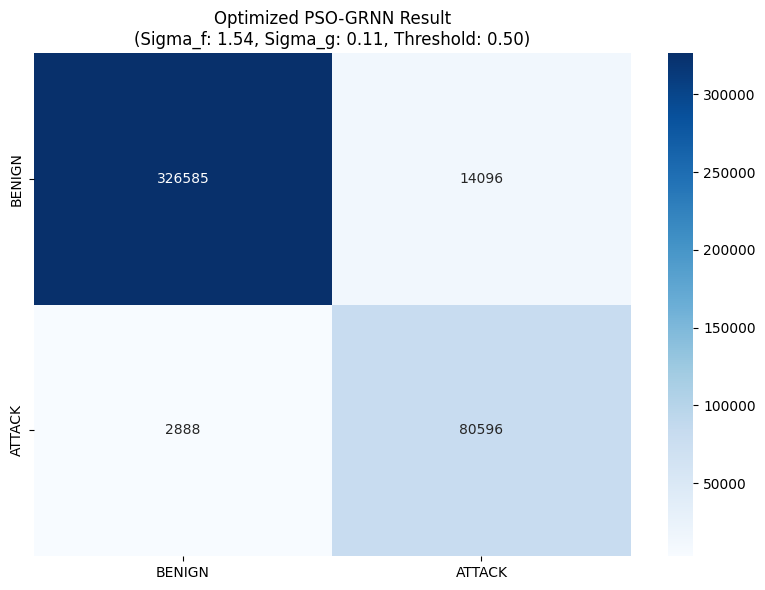


优化结果已保存至 optimization_results.json


In [ ]:
# ==========================================
# 最终测试阶段：使用所有优化后的参数
# ==========================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("[最终测试] 使用所有优化参数")
print("="*60)

# 1. 计算测试集增强特征
risk_test_final = compute_ffta_risk(
    X_test, ffta_mean, ffta_std, best_sigma_f, importance=importance_weights
).reshape(-1,1)

X_test_final = np.column_stack((X_test, risk_test_final))

X_test_final = scaler_final.transform(X_test_final)

# 2. 使用最优阈值构建最终模型
final_model = FastGRNN(sigma=best_sigma_g, threshold=best_threshold)
final_model.fit(X_train_final, y_train_condensed)

# 3. 执行预测
y_pred = final_model.predict(X_test_final)

# 4. 输出结果
target_names = ['BENIGN', 'ATTACK']
accuracy = np.mean(y_pred == y_test)
print(f"\n{'='*60}")
print("最终结果汇总:")
print("="*60)
print(f">>> 优化后准确率: {accuracy * 100:.2f}%")
print(f">>> 最优特征数量: {len(selected_features)}")
print(f">>> 最优压缩比: 攻击{best_ratio[0]*100:.1f}%/正常{best_ratio[1]*100:.1f}%")
print(f">>> 最优模糊宽度 (Sigma_f): {best_sigma_f:.4f}")
print(f">>> 最优平滑参数 (Sigma_g): {best_sigma_g:.4f}")
print(f">>> 最优分类阈值: {best_threshold:.3f}")
print(f"\n{'='*60}")
print("详细分类报告:")
print("="*60)
print(classification_report(y_test, y_pred, target_names=target_names))

# 5. 绘制混淆矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Optimized PSO-GRNN Result\n(Sigma_f: {best_sigma_f:.2f}, Sigma_g: {best_sigma_g:.2f}, Threshold: {best_threshold:.2f})')
plt.tight_layout()
plt.savefig('optimized_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. 保存优化结果
optimization_results = {
    'n_features': int(len(selected_features)),
    'compression_ratio_attack': float(best_ratio[0]),
    'compression_ratio_normal': float(best_ratio[1]),
    'best_sigma_f': float(best_sigma_f),
    'best_sigma_g': float(best_sigma_g),
    'best_threshold': float(best_threshold),
    'accuracy': float(accuracy),
    'macro_f1': float(f1_score(y_test, y_pred, average='macro'))
}

import json
with open('optimization_results.json', 'w') as f:
    json.dump(optimization_results, f, indent=4)

print("\n优化结果已保存至 optimization_results.json")